how can we support fast “give me 20 similar songs” queries when feature vectors are high-dimensional?

11/11-2025

Cluster the songs based on the feature vectors:<br> 
Algorithms like **k-means** or **DBSCAN** can be used for the clustering. <br>
Optionally, it is possible to build a **k-nearest-neighbour graph** from similarity scores and run a graph clustering method (e.g. **community detection**) to find “music communities”.

### **Cluster the LSH data:** 

Note: The previous step (**Step 2**), did Locality Sensitive Hashing (LSH) on the feature vectors to generate approximate nearest neighbours.
<br>
LSH maps similar songs into the same or nearby hash buckets with high probability. These buckets allow us to quickly retrieve candidate sets of similar songs without computing all pairwise distances, between every single vector.
<br>
During clustering, this pre-processing step can significantly reduce computation time, since comparisons can be limited to items within the same or similar buckets instead of the entire dataset.
<br>
<br>
Thus, LSH acts as a pre-treatment that enables scalable similarity search and accelerates the downstream clustering, performed in this notebook. 

**Getting required Python libraries:**

In [62]:
#Required packages: 
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.cluster import DBSCAN

from pathlib import Path

from collections import Counter, defaultdict

from sklearn.metrics import pairwise_distances_argmin

**Relevant paths**

In [ ]:
ARTIFACT_DIR = Path("../artifacts")

**Loading data and pre-treating it:**

In [25]:
#Load song data and its features: 
df_main = pd.read_csv("../dataset_with_lastfm_all.csv")
df_main = df_main.reset_index(drop=True)
df_main.drop(columns=["Unnamed: 0"], inplace=True) #This is an irrelevant, extra index column, which we can just get rid of. 
X = df_main.select_dtypes(include=[np.number]).to_numpy()

display(df_main.head(3)) #The dataframe with all of the feature data for all songs. 
print("Only numeric data (before treatment):")
print(X[:3]) #The numeric feature data for all songs. 

# -----------------------------
# Impute and scale the numeric data
# -----------------------------

#As there are NA values, we wanna fill out those - for demonstration purposes, we can just fill in the mean value for the given column. 
#This can potentially be changed later. 
imputer = SimpleImputer(strategy="mean") #Can be changed later. For now the mean value will be used to impute. 
X_imputed = imputer.fit_transform(X)
X = X_imputed  # replace original X (numeric feature data)

#Scale data - this is e.g. to make PCA plot easier to read, later: 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,liveness,valence,tempo,time_signature,track_genre,track_search,lfm_playcount,lfm_listeners,lfm_duration_ms,lfm_tags
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,NaN,0.676,0.461,1,...,0.358,0.715,87.917,4,acoustic,Comedy - Gen Hoshino,1908936.0,154089.0,230000.0,j-pop;japanese;rnb;jazz;pop;jpop;the best
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,NaN,0.420,0.166,1,...,0.101,0.267,77.489,4,acoustic,Ghost - Acoustic - Ben Woodward,37544.0,4502.0,149000.0,indie;rock;christian;1 in 360
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,NaN,0.438,0.359,0,...,0.117,0.120,76.332,4,acoustic,"To Begin Again - Ingrid Michaelson, ZAYN",374857.0,52055.0,210000.0,female vocalists;singer-songwriter;indie;acous...


Only numeric data (before treatment):
[[ 7.300000e+01  2.306660e+05           nan  6.760000e-01  4.610000e-01
   1.000000e+00 -6.746000e+00  0.000000e+00  1.430000e-01  3.220000e-02
   1.010000e-06  3.580000e-01  7.150000e-01  8.791700e+01  4.000000e+00
   1.908936e+06  1.540890e+05  2.300000e+05]
 [ 5.500000e+01  1.496100e+05           nan  4.200000e-01  1.660000e-01
   1.000000e+00 -1.723500e+01  1.000000e+00  7.630000e-02  9.240000e-01
   5.560000e-06  1.010000e-01  2.670000e-01  7.748900e+01  4.000000e+00
   3.754400e+04  4.502000e+03  1.490000e+05]
 [ 5.700000e+01  2.108260e+05           nan  4.380000e-01  3.590000e-01
   0.000000e+00 -9.734000e+00  1.000000e+00  5.570000e-02  2.100000e-01
   0.000000e+00  1.170000e-01  1.200000e-01  7.633200e+01  4.000000e+00
   3.748570e+05  5.205500e+04  2.100000e+05]]


/home/henrikk17/miniconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: [2]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


**Data exploration - PCA of song data (color based on genre):**

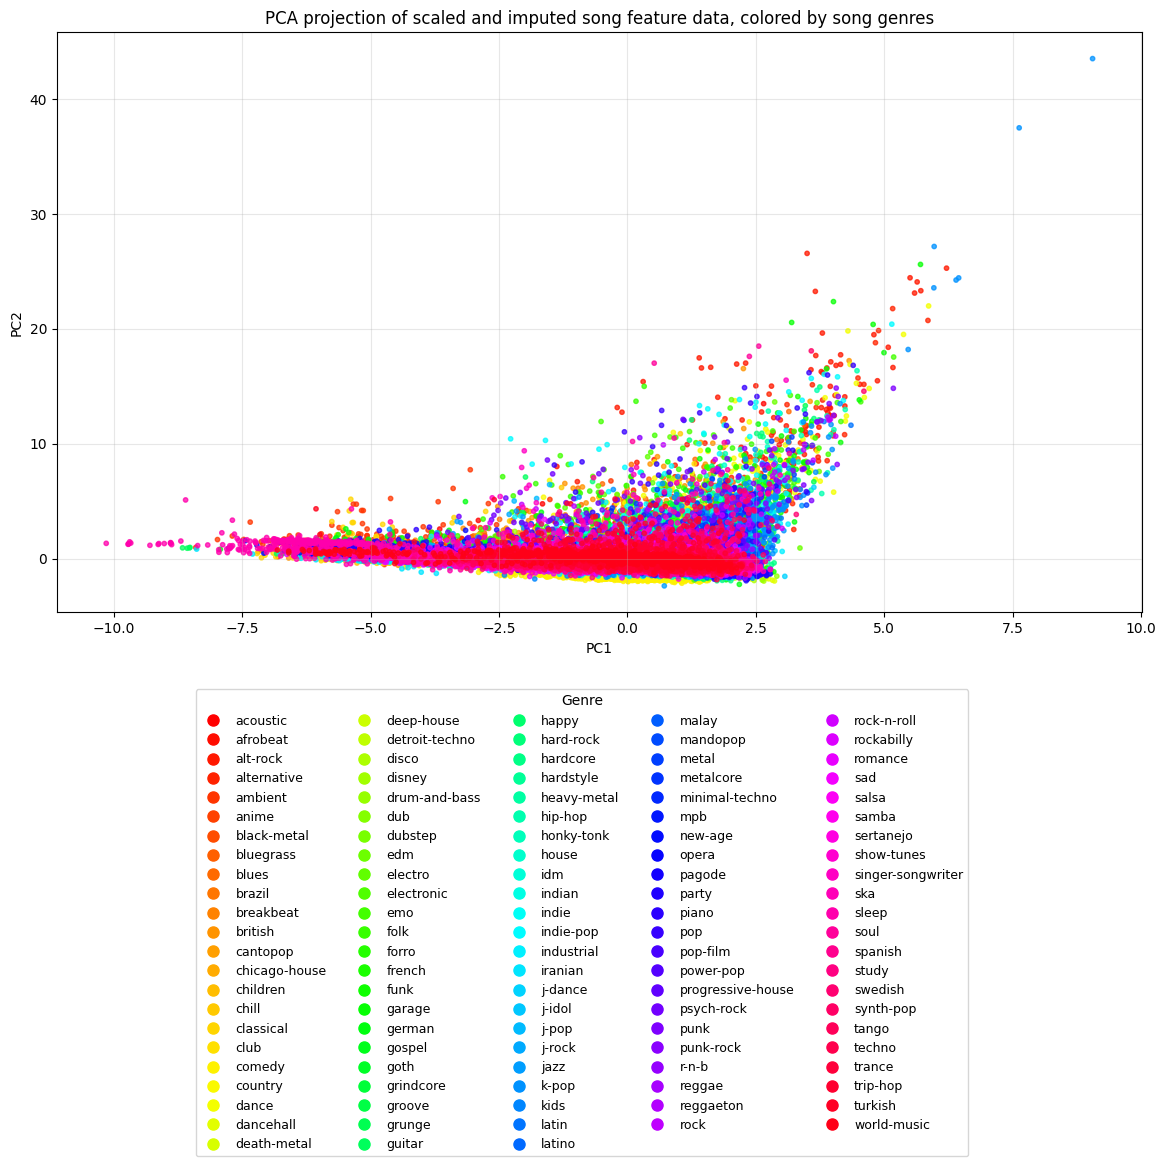

In [26]:
# -----------------------------
# Prepare labels
# -----------------------------
genres = df_main["track_genre"].astype("category")
genre_names = genres.cat.categories
genre_codes = genres.cat.codes.values
num_genres = len(genre_names)

# -----------------------------
# PCA
# -----------------------------
pca = PCA(n_components=2) #2d
X_pca = pca.fit_transform(X_scaled) #Use scaled data for PCA plot

# -----------------------------
# High-contrast colormap
# -----------------------------
colors = plt.cm.hsv(np.linspace(0, 1, num_genres)) #defines a distinct set of colors for the groups. 
cmap = ListedColormap(colors)

# -----------------------------
# Figure
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 10))
# Increase bottom margin to make room for horizontal legend
fig.subplots_adjust(bottom=0.3)

# -----------------------------
# Scatter plot
# -----------------------------
scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=genre_codes,
    cmap=cmap,
    s=10,
    alpha=0.75
)

ax.set_title("PCA projection of scaled and imputed song feature data, colored by song genres")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(alpha=0.3)

# -----------------------------
# Legend (horizontal, 5 columns, safely below the plot)
# -----------------------------
handles = [
    plt.Line2D([], [], marker='o', linestyle='', markersize=8, color=colors[i])
    for i in range(num_genres)
]


fig.legend(
    handles,
    genre_names,
    title="Genre",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.25),  # move the legend further down
    ncol=5,                        # horizontal 5-column layout
    fontsize=9
)

plt.show()


### **Normal K-means clustering:**

In [27]:
# -----------------------------
# Define k using number of genres
# -----------------------------
k_value = df_main["track_genre"].nunique() 

print()
print("K value is set equals to amount of different genres in dataset:", k_value)

# -----------------------------
# Fit global K-means
# -----------------------------
kmeans = KMeans(
    n_clusters=k_value,
    init="k-means++",   #k-means++ algorithm: initializes the centroids + helps speed up initialization and quality of clustering. 
    n_init="auto",      #The algortihm will automatically pick the amount of times to run with different centroid seeds. 
    random_state=42
)

kmeans.fit(X_scaled)
labels = kmeans.labels_

# -----------------------------
# Add cluster labels back to the dataframe
# -----------------------------
df_main["main_k_mean_cluster"] = labels 
#We will also use another approach for K-means combined with LSH. So for now we will name this one the "main" approach. 

print("Clustering complete:")
display(df_main[["track_genre", "main_k_mean_cluster"]].head(3))


K value is set equals to amount of different genres in dataset: 113
Clustering complete:


,track_genre,main_k_mean_cluster
0,acoustic,20
1,acoustic,106
2,acoustic,54


In [28]:
#Distribution of song genres in different K-means clusters: 
df_cluster_genre_count_compared = pd.crosstab(df_main['track_genre'], df_main['main_k_mean_cluster'])

display(df_cluster_genre_count_compared.head(3))

main_k_mean_cluster,0,1,2,3,4,5,6,7,8,9,...,103,104,105,106,107,108,109,110,111,112
track_genre,,,,,,,,,,,,,,,,,,,,,
acoustic,11,19,6,0,37,2,6,0,2,0,...,9,3,0,106,3,25,4,1,0,0
afrobeat,8,38,0,2,1,0,4,9,0,3,...,4,35,0,4,36,7,61,8,8,57
alt-rock,3,21,23,0,5,17,2,0,0,4,...,5,5,0,2,2,4,9,0,0,0


**_PCA plotting main K-means clustering_:**

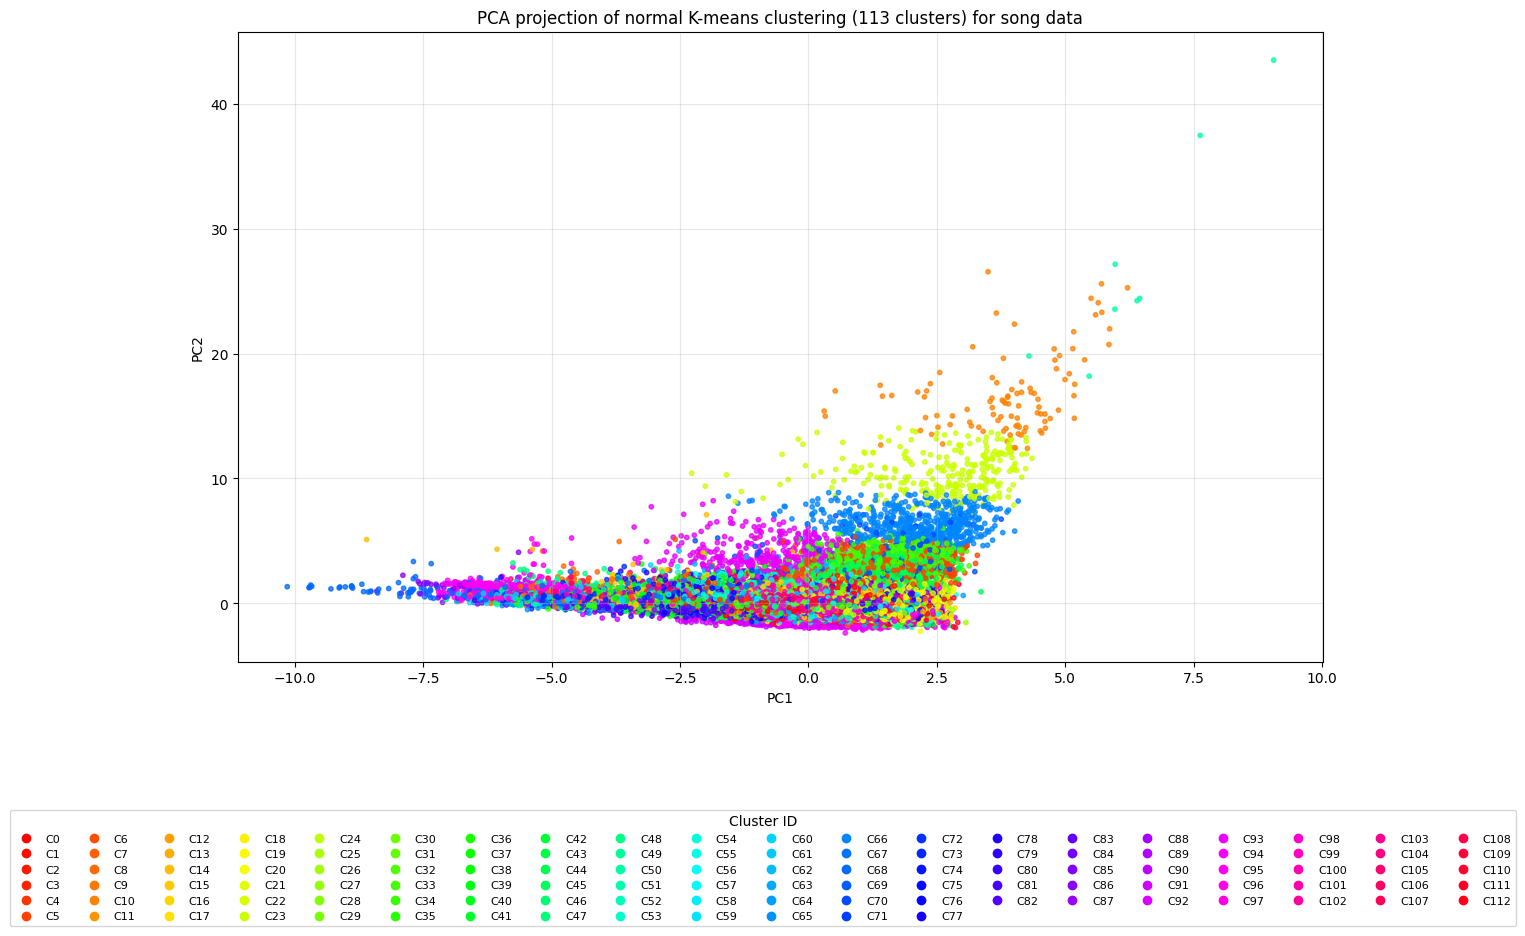

In [29]:
# -----------------------------
# PCA
# -----------------------------
pca = PCA(n_components=2) #make it 2d
X_pca = pca.fit_transform(X_scaled) #using scaled data. 

num_clusters = k_value

# -----------------------------
# High-contrast colormap (turbo)
# -----------------------------
colors = plt.cm.hsv(np.linspace(0, 1, num_clusters))

cmap = ListedColormap(colors)

# -----------------------------
# Figure
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 10))
fig.subplots_adjust(bottom=0.25)   # Make room at bottom for wide legend

# -----------------------------
# Scatter plot
# -----------------------------
scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    cmap=cmap,
    s=10,
    alpha=0.75
)

ax.set_title(f"PCA projection of normal K-means clustering ({k_value} clusters) for song data")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(alpha=0.3)

# -----------------------------
# Legend (horizontal segmentation)
# -----------------------------
ncols = 20  #Decides how the amount of columns in the legends is divided up. 

handles = [
    plt.Line2D([], [], marker='o', linestyle='', markersize=6, color=colors[i])
    for i in range(num_clusters)
]

fig.legend(
    handles,
    [f"C{i}" for i in range(num_clusters)],
    title="Cluster ID",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=ncols,
    fontsize=8
)

plt.show()


## **DBSCAN clustering:**

In [ ]:
# -----------------------------
# DBSCAN clustering
# -----------------------------
print("Running DBSCAN, please wait a bit...")
dbscan = DBSCAN(
    eps=2,        # maximum radius between neighbor samples (too small = lot of data gets classified as noise)
    min_samples=5,  # numbers of neighbors required to be considered a 'core point'
    metric='euclidean',
    n_jobs=-1       # -1 = Use all possible CPUs/ parallelize. 
)

labels = dbscan.fit_predict(X_scaled)

# -----------------------------
# Add cluster labels back to df
# -----------------------------
df_main['dbscan_cluster'] = labels #Save the cluster labels, from the DBSCAN, in a column in the dataframe. 


# Summary
n_clusters = len(set(labels)) - (1 if -1 in labels else 0) #Subtract 1 from the number of clusters, if there is a noise cluster (number = -1). 
n_noise = np.sum(labels == -1)
n_total = np.sum(labels)

print()
print(f"Number of clusters found: {n_clusters}")
print(f"Number of noise points: {n_noise} out of {n_total}")
print(f"% amount of noise points: {round(n_noise/n_total*100, 2)}%")

#Note: at ep = 1.5 and min_samples = 5, you get ~42% noise points, which is too high. 

Running DBSCAN, please wait a bit...

Number of clusters found: 57
Number of noise points: 5086 out of 79937
% amount of noise points: 6.36%


In [32]:
#Distribution of song genres in different DBSCAN clusters: 
df_cluster_genre_count_compared = pd.crosstab(df_main['track_genre'], df_main['dbscan_cluster'])

display(df_cluster_genre_count_compared.head(3))

dbscan_cluster,-1,0,1,2,3,4,5,6,7,8,...,47,48,49,50,51,52,53,54,55,56
track_genre,,,,,,,,,,,,,,,,,,,,,
acoustic,16,144,652,2,66,1,17,3,8,2,...,0,0,0,0,0,0,0,0,0,0
afrobeat,50,417,436,0,16,0,16,0,2,7,...,0,0,0,0,0,0,0,0,0,0
alt-rock,130,226,390,0,15,2,6,0,2,0,...,0,0,0,0,0,0,0,0,0,0


Note: Cluster number '-1' is the noise cluster. 

**_PCA plotting DBSCAN clustering_:**

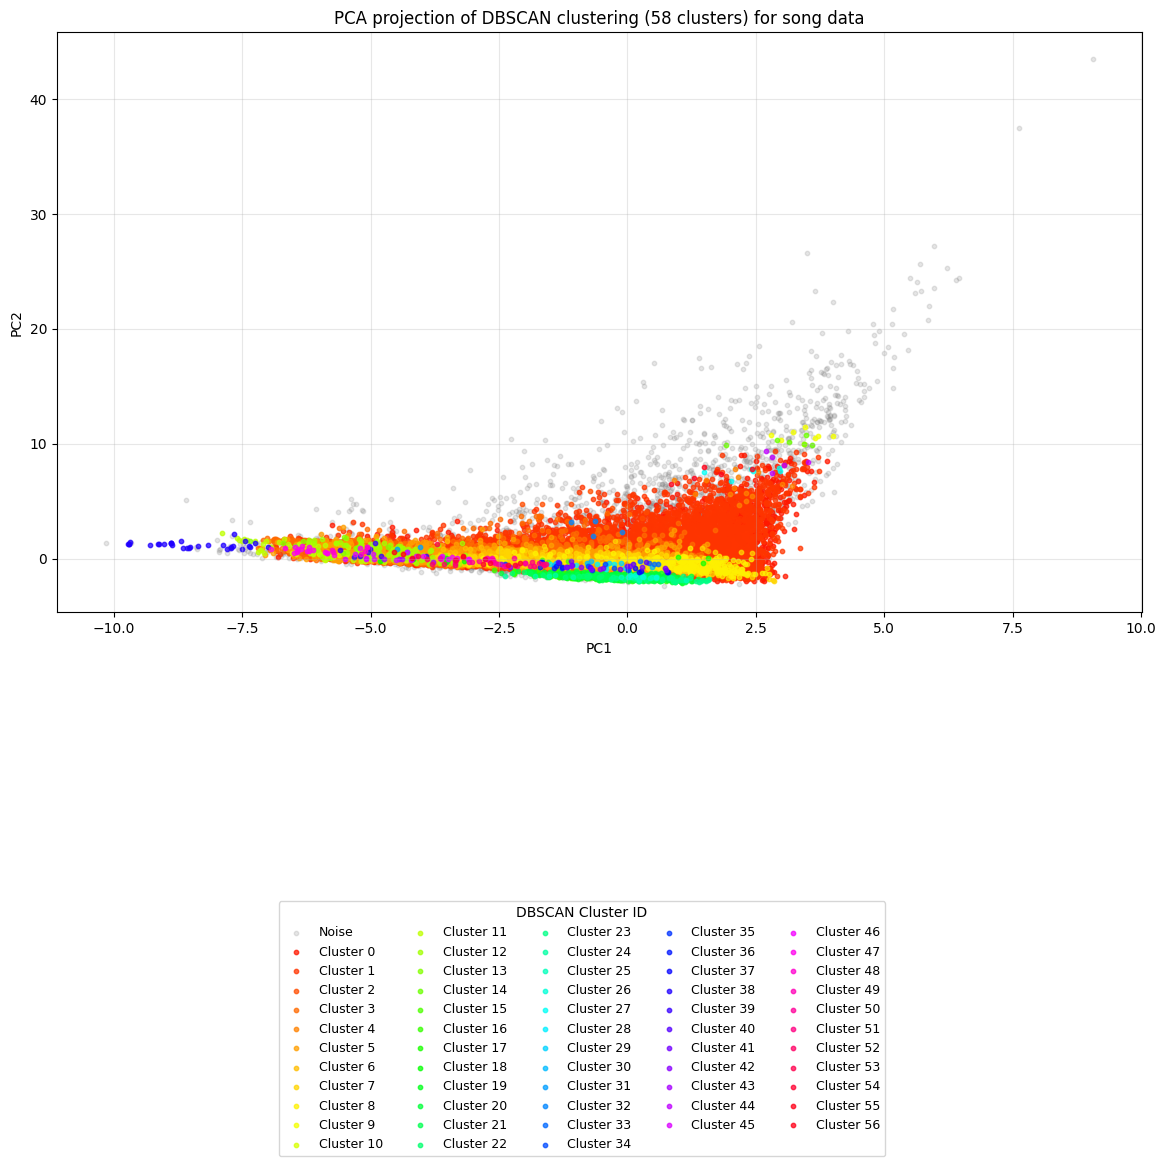

In [33]:
# -----------------------------
# PCA
# -----------------------------
pca = PCA(n_components=2) #2d
X_pca = pca.fit_transform(X_scaled) #using scaled (and imputed) data

# -----------------------------
# DBSCAN clusters
# -----------------------------
unique_labels = np.unique(labels)
num_clusters = len(unique_labels)

# High-contrast colors for clusters (ignore Noise)
cluster_labels = [l for l in unique_labels if l != -1]
colors = plt.cm.hsv(np.linspace(0, 1, len(cluster_labels)))
cmap = ListedColormap(colors)

# -----------------------------
# Figure
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 10))
fig.subplots_adjust(bottom=0.3)  # leave space for horizontal legend

# -----------------------------
# Scatter plot
# -----------------------------
handles = []
for i, label in enumerate(unique_labels):
    idx = labels == label
    if label == -1:
        # Noise points: gray & transparent
        sc = ax.scatter(
            X_pca[idx, 0],
            X_pca[idx, 1],
            s=10,
            alpha=0.2,
            color='gray',
            label='Noise'
        )
    else:
        sc = ax.scatter(
            X_pca[idx, 0],
            X_pca[idx, 1],
            s=10,
            alpha=0.75,
            color=colors[i if i < len(colors) else -1],  # safe indexing
            label=f'Cluster {label}'
        )
    handles.append(sc)


ax.set_title(f"PCA projection of DBSCAN clustering ({num_clusters} clusters) for song data")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(alpha=0.3)

# -----------------------------
# Legend (horizontal, 5 columns)
# -----------------------------
fig.legend(
    handles,
    [h.get_label() for h in handles],
    title="DBSCAN Cluster ID",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=5,
    fontsize=9
)

plt.show()


## **LSH-based super-clustering combined with K-means clustering:**

**Background:** <br>
One of the incentives of this project was to design a quick algorithm to for recommending Spotify music. 
Given that objective, it should also be able to quickly compute clusters, <br>
and subsequently use these clusters, <br> 
sample similar songs from. <br>
<br>
It was hypothesised that the clusters would be good subsets to sample from, <br>
as similar songs would be likely to cluster due to their similarity.  

With high computation speed in mind, <br> 
it seemed reasonable to include the previously calculated LSH signatures <br>
and use them as offset for determining super-clusters of some-what similar songs. <br>
<br>
Using the computed LSH super-cluster as starting point, <br>
it then seemed like an intriguing opportunity to do K-means clustering on these super-clusters, <br>
as a way to potentially pre-divide the different groupings + in an attempt to reduce computation time of the k-means. 

**Loading LSH signature data from last notebook:**

In [ ]:
LSH = np.load("../lsh_signatures.npz") #Loading LSH signatures, generated by previous notebook (number 2.)

#Extract some info about the LSH signatures
lsh_bits = LSH["lsh_bits"]           # shape (n_items, 128)
n_tables = int(LSH["n_tables"])      # 8
n_bits_per_table = int(LSH["n_bits_per_table"])  # 16
n_items = lsh_bits.shape[0]

# Split lsh_bits into tables
table_sigs = np.split(lsh_bits, n_tables, axis=1)  # 8 tables

print("LSH bits shape:", lsh_bits.shape)

LSH bits shape: (55129, 128)


**LSH-aided super-clustering:**

In [41]:
#Looping over all buckets in all tables and creating a dict: 
n_items = lsh_bits.shape[0]
table_sigs = lsh_bits.reshape(n_items, n_tables, n_bits_per_table)

# buckets_per_table[t][bucket_signature] = list of item indices
buckets_per_table = [defaultdict(list) for _ in range(n_tables)]

for t in range(n_tables):
    for i in range(n_items):
        bucket_id = tuple(table_sigs[i, t])
        buckets_per_table[t][bucket_id].append(i)

In [42]:
#Example of how the dict works: 
buckets_per_table[0][(1,0,1,1,0,0,0,0,1,1,1,1,0,0,1,0)] #First argument = table number, second argument = bucket ID. 

#Returns the index value of songs in a given bucket. 

[0, 18710, 30279, 39885, 42457, 47845, 47992]

In [43]:
# collision_count[(i,j)] tells how often i and j appear in same bucket
collision_count = defaultdict(int)

for t in range(n_tables):
    for bucket, items in buckets_per_table[t].items():
        if len(items) <= 1:
            continue
        for i in items:
            for j in items:
                if i < j:
                    collision_count[(i, j)] += 1

# Build final LSH groups
min_collisions = 2  # you can set 2, 3, 4 ... depending on strictness
lsh_groups = defaultdict(list)

for (i, j), c in collision_count.items():
    if c >= min_collisions:
        lsh_groups[i].append(j)
        lsh_groups[j].append(i)


In [44]:
#Example of how to use the dict: 
collision_count[(0, 39885)] #In how many tables does e.g. song no. 0 and no. 39885 have identical bits (in the same bucket).
#The answer is 2. I.e. they are in identical buckets/ overlap in 2 tables (2 out of 8 tables). 

2

In [45]:
#Making super-clusters from LSH signatures. It clusters based on when 2 or more datapoints share a lot of buckets. 

visited = set()
clusters = []

for i in range(n_items): #Up to 55129
    if i in visited:
        continue
    stack = [i]
    comp = [] 
    while stack:
        x = stack.pop() #Pull out most recent element. 
        if x in visited:
            continue
        visited.add(x) #If we already looked on number 1 in relation to number 1113, then 1113 in relation to 1 is not relevant. Simply skip. 
        comp.append(x) #All items in the cluster. Comp is wiped each time a new stack gets started. 
        stack.extend(lsh_groups[x])
    clusters.append(comp)

# clusters now contain LSH-based preclusters


In [ ]:
#Example of what the super-clusters look like: 

#First 2: 
print("How the clusters look like:")
print(clusters[:2])

print()
print(f"Amount of LSH super-clusters: {len(clusters)}") #9,190 super-clusters when n_items = 55,129. 

How the clusters look like:
[[0, 48840, 37804, 47867, 41150, 51388, 33396, 11161, 20681, 41491, 47744, 47845, 46972, 42457, 25611, 39885, 12778], [1, 51441, 43367, 40140, 4037, 20148, 9780, 2324, 28517, 49878, 23877, 38823, 46505, 28595, 41558, 27418, 36870, 10374, 45394, 48030, 50453, 13567, 20514, 48935, 48703, 34636, 10339, 54829, 16352, 46125, 45212, 9017, 4829, 9352, 15960, 54695, 29006, 10503, 51138, 50710, 9264, 47841, 50229, 52574, 30027, 42646, 47469, 53126, 47087, 31283, 40513, 33248, 53655, 28212, 13015, 5789, 11860, 10961, 30002, 2600, 13932, 43945, 37802, 37773, 24198, 25889, 10467, 1632, 52161, 34446, 14013, 50746, 3673, 7001, 54296, 45884, 3253, 67, 43336, 21405, 50500, 28216, 51710, 29402, 31051, 35112, 26697, 45870, 38966, 54308, 10588, 44514, 51160, 52702, 22347, 47652, 42267, 27338, 49993, 43071, 46205, 18262, 43890, 53641, 7299, 24285, 15360, 37345, 27383, 2965, 26951, 36945, 31144, 7510, 19663, 38377, 15777, 7524, 19798, 32150, 32019, 46596, 49971, 6762, 22974, 466

In [53]:
print("What the length distribution of super-clusters (first 20):")
print( [len(c) for c in clusters[:20]] ) #Length distribution of these clusters. 
#Note: Some of them are only 1s. 

What the length distribution of super-clusters (first 20):
[17, 242, 5, 30594, 227, 1, 1, 1, 3, 67, 2, 2, 6, 1, 291, 1, 1217, 482, 927, 11]


In [54]:
#Run LOCAL K-means inside each LSH super-cluster

local_centroids = []

k_local = 5  # pick 2–10 depending on granularity

for comp in clusters: #Iterate over each LSH cluster
    if len(comp) < k_local:
        # centroid = mean of members
        local_centroids.append(X_scaled[comp].mean(axis=0))    #If the cluster has fewer points than k_local, 
                                                        #skip K-means and use the mean of all points in the cluster as the centroid.
        continue
    
    km = KMeans(n_clusters=k_local, n_init='auto') #Run K-means on larger clusters
    km.fit(X_scaled[comp])
    local_centroids.append(km.cluster_centers_)

#Note: as usual, we are using the scaled (and imputed) data. 

In [ ]:
#Looking at the local centroids output: 

print(len(local_centroids))
print(len(local_centroids[0])) #k_local = 5, so there will be 5 clusters. 
print(local_centroids[0]) #5 k-means clusters which was made from the 'clusters' variable. 


9190
5
[[ 3.09838532e-01 -4.61971329e-02 -1.47610260e-01 -9.39158444e-01
   7.63801422e-01 -2.08487841e-03  6.82974486e-02 -9.89777970e-02
   1.18157488e+00 -5.52526771e-01 -2.89909714e-01 -1.13178928e-01
  -2.81225406e-01  2.26987667e-01 -1.09661556e-01 -1.15389857e-01
  -1.09401030e-01]
 [-1.16636704e+00  1.44605790e+00 -2.33981703e+00 -1.79735217e+00
   1.60739136e+00 -2.18202170e+00 -1.31547315e+00 -4.44601819e-01
   1.91530928e+00  2.27403630e+00 -5.25060170e-01 -1.55687260e+00
  -9.70857303e-01 -1.95024822e+00 -2.11219383e-01 -2.90773126e-01
   1.60107337e+00]
 [-1.11426567e+00  4.97087882e-01  7.02009910e-01  5.83942133e-01
   5.76336991e-01  3.12780960e-01 -1.31547315e+00 -2.55724019e-01
  -9.65812449e-01  5.12046078e-01 -4.08644134e-01 -2.12900708e-01
  -1.60863819e-01  2.26987667e-01 -2.11756924e-01 -2.90804180e-01
  -7.01029555e-01]
 [ 1.28239750e+00 -5.34469596e-01  1.69830243e-01  6.18733771e-01
  -1.20457510e+00  8.25464003e-01  7.60182750e-01  6.92856058e-01
  -9.7252513

In [ ]:
#Flatten: 

#Unifying the centroids. 
#Combine all centroids (from both small and large clusters) into a single matrix, where each row is a centroid.

local_centroids = np.vstack([
    c if c.ndim == 2 else np.expand_dims(c, axis=0) #If centroid is already 2D (c.ndim == 2), use it as-is.
                                                    #If c is 1D (e.g., from a small cluster), reshape it to 2D 
                                                    #using np.expand_dims(c, axis=0). 
                                                    #This adds a new axis, converting a 1D array of shape (n_features,) to (1, n_features)
    for c in local_centroids
])

#In short: Converts shape (n_features,) to (1, n_features), for the really small clusters. 

In [59]:
#After flattening: 
print(len(local_centroids))
print(local_centroids)


11614
[[ 0.30983853 -0.04619713 -0.14761026 ... -0.10966156 -0.11538986
  -0.10940103]
 [-1.16636704  1.4460579  -2.33981703 ... -0.21121938 -0.29077313
   1.60107337]
 [-1.11426567  0.49708788  0.70200991 ... -0.21175692 -0.29080418
  -0.70102956]
 ...
 [ 1.02189063 -0.52864592 -0.35674753 ...  0.17906287  0.72093455
  -0.18812579]
 [ 1.2823975   0.73614976 -1.04578015 ...  0.38865284  1.52911258
   1.00705925]
 [ 0.55297827  0.43720967 -0.14947756 ... -0.20807896 -0.2850737
   0.74225777]]


In [60]:
#Run global K-means on local centroids:

k_global = 50  # final number of clusters

km_global = KMeans(
                   n_clusters=k_global, #k = 50
                   n_init='auto')

km_global.fit(local_centroids)

final_centroids = km_global.cluster_centers_

In [ ]:
#Assign points to the final centroid: 
labels_global = pairwise_distances_argmin(X, final_centroids)


In [64]:
labels_global

array([49, 45, 49, ..., 45, 49, 49], shape=(73608,))

PCA plot it:

In [65]:
#Making a function for PCA plotting clusters: 

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# -------------------------------------------------
# Input:
#   X               : (n_items, d) feature matrix
#   labels_global   : (n_items,) cluster assignments
# -------------------------------------------------

def plot_clusters_pca(X, labels_global, sample_size=20000):
    n = X.shape[0]

    # Optional: downsample large datasets for visualization
    if n > sample_size:
        idx = np.random.choice(n, size=sample_size, replace=False)
        X_vis = X[idx]
        labels_vis = labels_global[idx]
    else:
        X_vis = X
        labels_vis = labels_global

    # PCA → 2D
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_vis)

    # Create figure
    plt.figure(figsize=(10, 7))

    # Avoid color issues: pass labels as *a separate argument*
    # and let matplotlib assign a colormap
    scatter = plt.scatter(
        X_pca[:, 0], 
        X_pca[:, 1], 
        c=labels_vis,
        s=8,
        alpha=0.7,
        cmap="tab20"
    )

    # Add colorbar
    cbar = plt.colorbar(scatter)
    cbar.set_label("Cluster ID", rotation=270, labelpad=15)

    plt.title("PCA Visualization of LSH-accelerated K-means Clusters")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")

    plt.tight_layout()
    plt.show()


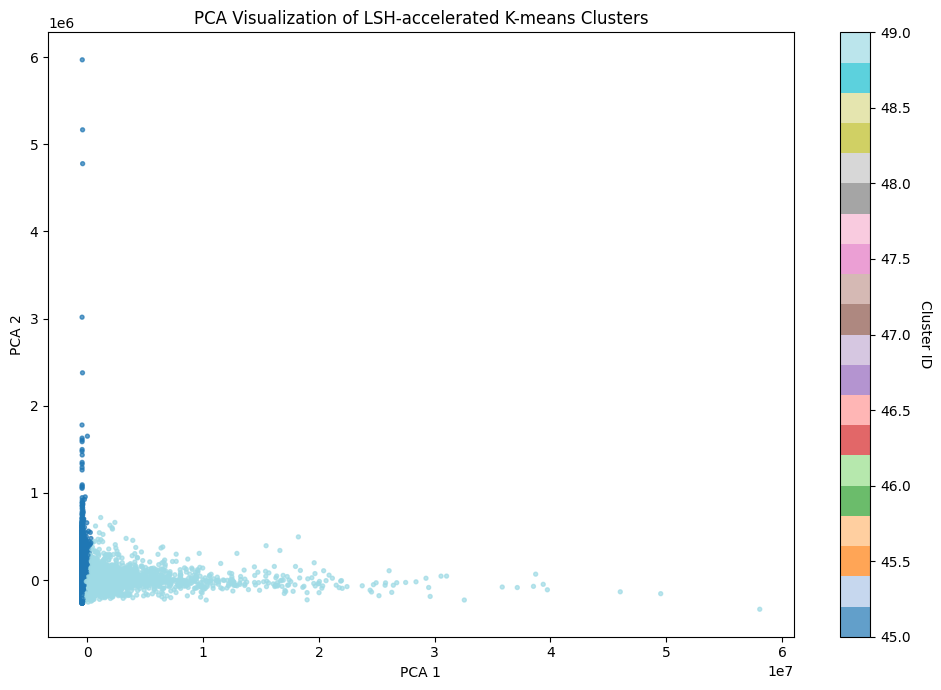

In [66]:
plot_clusters_pca(X, labels_global)

**Load main data + LSH signatures from last notebook:**

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

# Load LSH signatures
ARTIFACT_DIR = Path("../artifacts")
LSH = np.load("../lsh_signatures.npz")
lsh_bits = LSH["lsh_bits"]           # shape (n_items, 128)
n_tables = int(LSH["n_tables"])      # 8
n_bits_per_table = int(LSH["n_bits_per_table"])  # 16

print("LSH bits shape:", lsh_bits.shape)

# Load real features
df_main = pd.read_csv("../dataset_with_lastfm_all.csv")
df_main = df_main.reset_index(drop=True)
df_main.drop(columns=["Unnamed: 0"], inplace=True) #This is an irrelevant column, which we can just get rid of. 
X = df_main.select_dtypes(include=[np.number]).to_numpy()

n_items = lsh_bits.shape[0]


LSH bits shape: (55129, 128)


In [6]:
df_main.head(3)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,liveness,valence,tempo,time_signature,track_genre,track_search,lfm_playcount,lfm_listeners,lfm_duration_ms,lfm_tags
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,NaN,0.676,0.461,1,...,0.358,0.715,87.917,4,acoustic,Comedy - Gen Hoshino,1908936.0,154089.0,230000.0,j-pop;japanese;rnb;jazz;pop;jpop;the best
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,NaN,0.420,0.166,1,...,0.101,0.267,77.489,4,acoustic,Ghost - Acoustic - Ben Woodward,37544.0,4502.0,149000.0,indie;rock;christian;1 in 360
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,NaN,0.438,0.359,0,...,0.117,0.120,76.332,4,acoustic,"To Begin Again - Ingrid Michaelson, ZAYN",374857.0,52055.0,210000.0,female vocalists;singer-songwriter;indie;acous...


In [7]:
#There are NA values, which need to be replaced using imputers: 
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean") #Can be changed later. For now the mean value will be used to impute. 
X_imputed = imputer.fit_transform(X)

X = X_imputed  # replace original X

/home/henrikk17/miniconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: [2]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


Run time: Imputation takes around 46 seconds. 

In [8]:
# Split lsh_bits into tables
table_sigs = np.split(lsh_bits, n_tables, axis=1)  # 8 tables

In [9]:
# #Making a list of dicts. Dicts represents the tables. 
# #They allow the lookup of songs associated with different buckets for each table in the LSH signature. 
# from collections import defaultdict

# buckets_per_table = [defaultdict(list) for _ in range(n_tables)]

# for t, table in enumerate(table_sigs):
#     for i, row in enumerate(table):
#         bucket_id = tuple(row.tolist())  # hashable 16-bit signature
#         buckets_per_table[t][bucket_id].append(i)


In [10]:
# #The list of dicts, generated above, allows us to look up the table and bits values for the LSH signatures: 
# table_number = 0
# bucket_id = (1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0)

# print(f"The songs (index-based) in table no. {table_number} which have this particular bucket ID '{bucket_id}' are as follows:", buckets_per_table[table_number][bucket_id], sep="\n\n")

In [11]:
# lsh_bits[0] #Looking at the 128 bits in the LSH signature for the very first datapoint/ song. 

In [12]:
# print("Amount of bits (binary yes/no questions):", len(lsh_bits[0]))
# print("Amount of tables (how many pieces the bits are divided into):", n_tables)
# print("Amount of bits (questions) pr. table:", n_bits_per_table)
# print("Amount possible of bucket combinations pr. table:", 2**n_bits_per_table)

# #Reminder: Each table contains buckets containing of 16 bits. 
# #Each bucket represents each different combinations of 16 bits, for that particular table.

**Explaining LSH and the data structure:**<br>
For each datapoint, you ask it 128 questions yes/no (position relative to the 128 random hyperplanes)? Depending on the position, it will either be a yes (1) or a no (0). (Question could e.g. be "is the coordinate in the direction of the normal vector of the given hyperplane? [yes/no]").
If you have, e.g., 8 tables, you start looking at the 16 answers to the questions at a time. (128questions/8tables=16). In other words, if the sequence of answers in table no. 1 is [1,0,...,1,1,0] (length of 16 questions), then this is a unique fingerprint. This specific sequence of answers/ fingerprint for this particular table is called a "bucket". There are several combination options when you have 16 questions in your bucket. In fact, there are 2^16 = 65536 combination options, i.e. there can be 65536 different buckets in this table! If 2 items end up in the same bucket for table 1, then they have identical answers for the first 16 questions. 
Similar datapoints will be on the same side of most hyperplanes, i.e. get mostly the same answers to questions. The pattern in their answers (bits) will be highly similar. If two items differ in only 1 or 2 answers (bits) out of 16, they go in different buckets. But across 8 tables, they'll likely match in at least one table.

In [13]:
# #Checking that bucket size looks correct: 
# bucket_sizes = [len(members) for table in buckets_per_table for members in table.values()]
# print("Total hash buckets:", len(bucket_sizes))
# print("Average bucket size:", np.mean(bucket_sizes))

In [14]:
# print(bucket_sizes[:5]) #Amount of songs in each buckets. Does not differentiate between tables. 
# #Only shows the first 5. 

In [15]:
# def get_hash_values(lsh_bits, n_tables, n_bits_per_table):
#     """
#     Convert binary bits to integer hash values for each table.
    
#     Returns: array of shape (n_items, n_tables) with integer hash values
#     """
#     n_items = lsh_bits.shape[0]
#     hash_values = np.zeros((n_items, n_tables), dtype=np.uint32)
    
#     for table_idx in range(n_tables):
#         start_bit = table_idx * n_bits_per_table
#         end_bit = start_bit + n_bits_per_table
        
#         # Get bits for this table
#         table_bits = lsh_bits[:, start_bit:end_bit]
        
#         # Convert binary to integer (each row becomes one hash value)
#         powers = 2 ** np.arange(n_bits_per_table)
#         hash_values[:, table_idx] = table_bits @ powers
    
#     return hash_values

# # Get hash values for all items
# hash_values = get_hash_values(lsh_bits, n_tables, n_bits_per_table)
# print("Hash values shape:", hash_values.shape)  # (n_items, 8)

# # Example: View all items in a specific bucket
# table_idx = 0  # Choose which table (0-7)
# bucket_id = hash_values[0, table_idx]  # Use item 0's hash as example

# items_in_bucket = np.where(hash_values[:, table_idx] == bucket_id)[0]
# print(f"\nTable {table_idx}, Bucket {bucket_id}:")
# print(f"Contains {len(items_in_bucket)} items: {items_in_bucket[:10]}...")

# # View these items' data
# print("\nFirst few items in bucket:")
# display(df_main.iloc[items_in_bucket])

**Build candidate neighborhoods:**

In [16]:
# #Fetching candidate neighbors, by filtering out too small buckets. 

# #Contains the amount of items in each bucket. 

# candidate_sets = [set() for _ in range(n_items)]

# for table in buckets_per_table:
#     for bucket_id, members in table.items():
#         if len(members) < 5:     # skip very small buckets
#             continue
#         for idx in members:
#             candidate_sets[idx].update(members)


In [17]:
# #Content of each bucket, unrelated to tables. 

# for i in range(0,3):
#     print(f"len: {len(candidate_sets[i])}",candidate_sets[i])

In [18]:
# print("Amount of hash buckets after removing small buckets (size less than 5):", len(candidate_sets))

In [19]:
# print("Avg candidate size:", np.mean([len(s) for s in candidate_sets]))
# print("Max candidate size:", np.max([len(s) for s in candidate_sets]))


In [20]:
# max(np.max([s for s in candidate_sets]))

**Remove duplicate candidate groups:**

In [21]:
# unique_groups = {}  # frozen_set → list of indices

# for idx, s in enumerate(candidate_sets):
#     key = frozenset(s)
#     if key not in unique_groups:
#         unique_groups[key] = []
#     unique_groups[key].append(idx)

# print("Unique candidate groups, aka. hash buckets after removing duplicates:", len(unique_groups))


**Done with data exploration |Time for LSH grouping and K-means:**

In [22]:
#Looping over all buckets in all tables and creating a dict: 

import numpy as np
from collections import defaultdict

n_items = lsh_bits.shape[0]
table_sigs = lsh_bits.reshape(n_items, n_tables, n_bits_per_table)

# buckets_per_table[t][bucket_signature] = list of item indices
buckets_per_table = [defaultdict(list) for _ in range(n_tables)]

for t in range(n_tables):
    for i in range(n_items):
        bucket_id = tuple(table_sigs[i, t])
        buckets_per_table[t][bucket_id].append(i)

In [23]:
buckets_per_table[0][(1,0,1,1,0,0,0,0,1,1,1,1,0,0,1,0)]

[0, 18710, 30279, 39885, 42457, 47845, 47992]

In [24]:
from collections import Counter, defaultdict

# collision_count[(i,j)] tells how often i and j appear in same bucket
collision_count = defaultdict(int)

for t in range(n_tables):
    for bucket, items in buckets_per_table[t].items():
        if len(items) <= 1:
            continue
        for i in items:
            for j in items:
                if i < j:
                    collision_count[(i, j)] += 1

# Build final LSH groups
min_collisions = 2  # you can set 2, 3, 4 ... depending on strictness
lsh_groups = defaultdict(list)

for (i, j), c in collision_count.items():
    if c >= min_collisions:
        lsh_groups[i].append(j)
        lsh_groups[j].append(i)


In [25]:
collision_count[(0, 39885)] #In how many tables does song no. 0 and no. 39885 have identical bits (in the same bucket).
#The answer is 2. I.e. they are in identical buckets/ overlap in 2 tables (2 out of 8 tables). 

2

In [26]:
#Making super-clusters from LSH signatures. It clusters based on when 2 or more datapoints share a lot of buckets. 

visited = set()
clusters = []

for i in range(n_items): #To 55129
    if i in visited:
        continue
    stack = [i]
    comp = [] #
    while stack:
        x = stack.pop() #Pull out most recent element. 
        if x in visited:
            continue
        visited.add(x) #If we already looked on number 1 in relation to number 1113, then 1113 in relation to 1 is not relevant. Simply skip. 
        comp.append(x) #All items in the cluster. Comp is wiped each time a new stack gets started. 
        stack.extend(lsh_groups[x])
    clusters.append(comp)

# clusters now contain LSH-based preclusters


In [27]:
print(clusters)
print("Amount of LSH clusters:", len(clusters))

[[0, 48840, 37804, 47867, 41150, 51388, 33396, 11161, 20681, 41491, 47744, 47845, 46972, 42457, 25611, 39885, 12778], [1, 51441, 43367, 40140, 4037, 20148, 9780, 2324, 28517, 49878, 23877, 38823, 46505, 28595, 41558, 27418, 36870, 10374, 45394, 48030, 50453, 13567, 20514, 48935, 48703, 34636, 10339, 54829, 16352, 46125, 45212, 9017, 4829, 9352, 15960, 54695, 29006, 10503, 51138, 50710, 9264, 47841, 50229, 52574, 30027, 42646, 47469, 53126, 47087, 31283, 40513, 33248, 53655, 28212, 13015, 5789, 11860, 10961, 30002, 2600, 13932, 43945, 37802, 37773, 24198, 25889, 10467, 1632, 52161, 34446, 14013, 50746, 3673, 7001, 54296, 45884, 3253, 67, 43336, 21405, 50500, 28216, 51710, 29402, 31051, 35112, 26697, 45870, 38966, 54308, 10588, 44514, 51160, 52702, 22347, 47652, 42267, 27338, 49993, 43071, 46205, 18262, 43890, 53641, 7299, 24285, 15360, 37345, 27383, 2965, 26951, 36945, 31144, 7510, 19663, 38377, 15777, 7524, 19798, 32150, 32019, 46596, 49971, 6762, 22974, 4660, 21289, 3613, 49373, 11360

In [28]:
print( [len(c) for c in clusters] ) #Length distribution of these clusters. 
#Note: Some of them are only 1s. 

[17, 242, 5, 30594, 227, 1, 1, 1, 3, 67, 2, 2, 6, 1, 291, 1, 1217, 482, 927, 11, 31, 75, 1, 1, 2, 1, 20, 1, 463, 1, 1, 34, 2, 3, 7, 28, 102, 7, 270, 3, 231, 14, 5, 4, 2, 1, 10, 169, 26, 1, 1, 42, 34, 20, 1, 35, 6, 56, 4, 1, 4, 248, 1, 11, 5, 1, 5, 2, 1, 14, 87, 13, 6, 8, 3, 281, 1, 27, 1, 2, 1, 4, 1, 1, 3, 1, 8, 118, 4, 1, 7, 1, 2, 13, 1, 1, 15, 117, 6, 1, 12, 60, 7, 428, 1, 2, 2, 5, 2, 10, 1, 1, 4, 1, 2, 1, 3, 1, 2, 5, 1, 1, 2, 29, 49, 98, 1, 6, 1, 4, 1, 1, 39, 1, 146, 1, 4, 2, 5, 1, 1, 8, 130, 1, 5, 25, 1, 1, 13, 32, 1, 5, 2, 3, 4, 11, 1, 86, 1, 9, 1, 1, 1, 8, 10, 27, 71, 7, 2, 1, 4, 1, 42, 1, 77, 1, 5, 1, 1, 21, 23, 1, 17, 14, 8, 44, 2, 1, 1, 7, 1, 1, 1, 2, 1, 15, 7, 4, 1, 1, 14, 1, 1, 1, 1, 2, 1, 48, 1, 1, 1, 31, 1, 1, 3, 1, 32, 7, 26, 26, 4, 1, 1, 4, 1, 4, 1, 3, 11, 2, 2, 9, 1, 2, 1, 8, 25, 1, 3, 3, 18, 1, 1, 1, 1, 1, 1, 1, 2, 1, 208, 1, 12, 1, 5, 16, 1, 1, 1, 21, 23, 3, 1, 25, 4, 20, 9, 1, 1, 2, 3, 10, 3, 1, 1, 1, 1, 1, 2, 1, 1, 4, 18, 1, 1, 2, 1, 1, 2, 1, 2, 6, 3, 2, 7, 3, 1, 1,

In [29]:
#Run LOCAL K-means inside each LSH cluster

from sklearn.cluster import KMeans

local_centroids = []

k_local = 5  # pick 2–10 depending on granularity

for comp in clusters: #Iterate over each LSH cluster
    if len(comp) < k_local:
        # centroid = mean of members
        local_centroids.append(X[comp].mean(axis=0))    #If the cluster has fewer points than k_local, 
                                                        #skip K-means and use the mean of all points in the cluster as the centroid.
        continue
    
    km = KMeans(n_clusters=k_local, n_init='auto') #Run K-means on larger clusters
    km.fit(X[comp])
    local_centroids.append(km.cluster_centers_)


In [30]:
#Inspect structure of clusters: 
print(len(clusters))
print(clusters[0])
print(len(clusters[0]))

9190
[0, 48840, 37804, 47867, 41150, 51388, 33396, 11161, 20681, 41491, 47744, 47845, 46972, 42457, 25611, 39885, 12778]
17


In [31]:
print(len(local_centroids))
print(len(local_centroids[0])) #k = 5, so there will be 5 clusters. 
print(local_centroids[0]) #5 k-means clusters which was made from the 'clusters' variable. 


9190
5
[[ 2.76000000e+01  2.10312600e+05  6.29000000e-01  6.15000000e-01
   5.80000000e+00 -7.30380000e+00  4.00000000e-01  7.60000000e-02
   2.21346440e-01  7.60420000e-02  1.76460000e-01  4.79000000e-01
   1.16043600e+02  4.00000000e+00  2.29420000e+03  7.43400000e+02
   4.80000000e+04]
 [ 5.90000000e+01  1.68533000e+05  5.89000000e-01  7.97000000e-01
   1.00000000e+00 -4.21300000e+00  1.00000000e+00  1.73000000e-01
   6.73000000e-04  0.00000000e+00  2.46000000e-02  7.87000000e-01
   1.74039000e+02  4.00000000e+00  9.05074500e+06  6.80296000e+05
   1.96000000e+05]
 [ 7.80000000e+01  2.16241000e+05  6.52500000e-01  5.79500000e-01
   4.50000000e+00 -5.61550000e+00  5.00000000e-01  2.25500000e-01
   4.15500000e-02  8.30505000e-04  2.24450000e-01  6.57000000e-01
   1.02841000e+02  4.00000000e+00  2.16942450e+06  1.90068500e+05
   2.15500000e+05]
 [ 3.28571429e+01  2.75151429e+05  5.91285714e-01  4.96714286e-01
   4.85714286e+00 -9.41357143e+00  7.14285714e-01  4.05714286e-02
   4.6673285

In [32]:
#Flatten:

#The code unifies centroids. 
#It combines all centroids (from both small and large clusters) into a single matrix, where each row is a centroid.

local_centroids = np.vstack([
    c if c.ndim == 2 else np.expand_dims(c, axis=0) #If centroid is already 2D (c.ndim == 2), use it as-is.
                                                    #If c is 1D (e.g., from a small cluster), reshape it to 2D 
                                                    #using np.expand_dims(c, axis=0). 
                                                    #This adds a new axis, converting a 1D array of shape (n_features,) to (1, n_features)
    for c in local_centroids
])

#In short: Converts shape (n_features,) to (1, n_features), for the really small clusters. 

In [33]:
print(len(local_centroids))
print(local_centroids)

11614
[[2.7600000e+01 2.1031260e+05 6.2900000e-01 ... 2.2942000e+03
  7.4340000e+02 4.8000000e+04]
 [5.9000000e+01 1.6853300e+05 5.8900000e-01 ... 9.0507450e+06
  6.8029600e+05 1.9600000e+05]
 [7.8000000e+01 2.1624100e+05 6.5250000e-01 ... 2.1694245e+06
  1.9006850e+05 2.1550000e+05]
 ...
 [5.4000000e+01 1.6922600e+05 4.9500000e-01 ... 8.4841600e+05
  1.8487600e+05 1.5400000e+05]
 [5.9000000e+01 3.1973300e+05 3.7200000e-01 ... 1.3030450e+06
  3.3234800e+05 3.2100000e+05]
 [4.5000000e+01 2.8416000e+05 5.3200000e-01 ... 8.6530000e+03
  1.3050000e+03 2.8400000e+05]]


In [34]:
#Run global K-means on local centroids:

k_global = 50  # final number of clusters

km_global = KMeans(n_clusters=k_global, n_init='auto')
km_global.fit(local_centroids)

final_centroids = km_global.cluster_centers_

In [35]:
#Assign points to the final centroid: 

from sklearn.metrics import pairwise_distances_argmin

labels_global = pairwise_distances_argmin(X, final_centroids)


In [36]:
labels_global

array([25, 20, 37, ..., 27, 27, 27], shape=(73608,))

PCA plot it:

In [37]:
#Making a function for PCA plotting clusters: 

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# -------------------------------------------------
# Input:
#   X               : (n_items, d) feature matrix
#   labels_global   : (n_items,) cluster assignments
# -------------------------------------------------

def plot_clusters_pca(X, labels_global, sample_size=20000):
    n = X.shape[0]

    # Optional: downsample large datasets for visualization
    if n > sample_size:
        idx = np.random.choice(n, size=sample_size, replace=False)
        X_vis = X[idx]
        labels_vis = labels_global[idx]
    else:
        X_vis = X
        labels_vis = labels_global

    # PCA → 2D
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_vis)

    # Create figure
    plt.figure(figsize=(10, 7))

    # Avoid color issues: pass labels as *a separate argument*
    # and let matplotlib assign a colormap
    scatter = plt.scatter(
        X_pca[:, 0], 
        X_pca[:, 1], 
        c=labels_vis,
        s=8,
        alpha=0.7,
        cmap="tab20"
    )

    # Add colorbar
    cbar = plt.colorbar(scatter)
    cbar.set_label("Cluster ID", rotation=270, labelpad=15)

    plt.title("PCA Visualization of LSH-accelerated K-means Clusters")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")

    plt.tight_layout()
    plt.show()


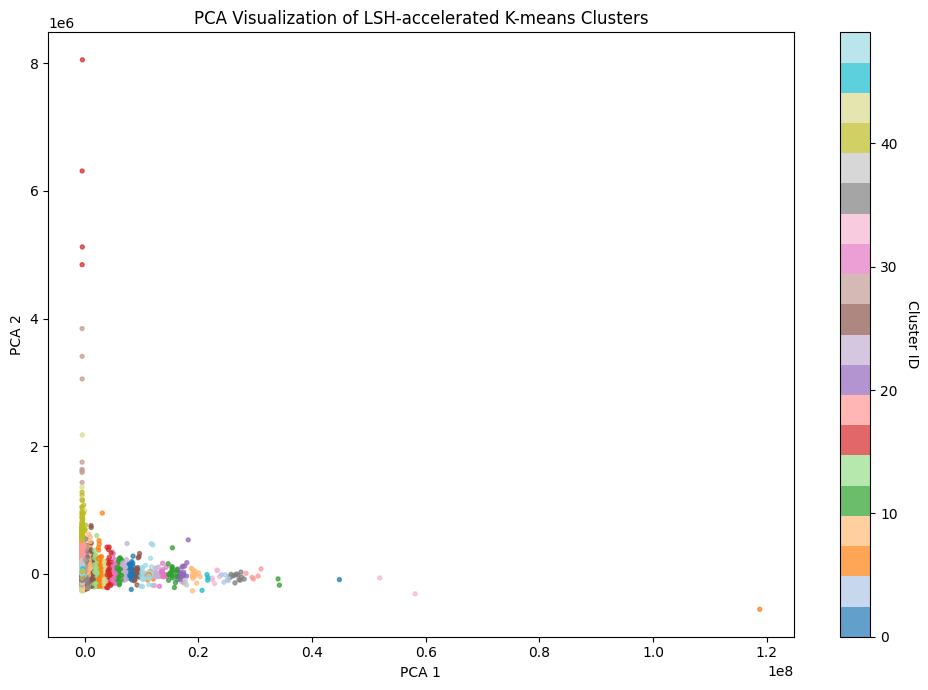

In [38]:
plot_clusters_pca(X, labels_global)

In [39]:
print(labels_global)

[25 20 37 ... 27 27 27]


**Doing K-means clustering on entire dataset:**

In [ ]:
display(df_main.head(3)) #The dataframe with all of the feature data for all songs. 

print(X) #The numeric feature data for all songs. 

########


import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
#from sklearn.impute import SimpleImputer


# -----------------------------
# Define k using number of genres
# -----------------------------
k_value = df_main["track_genre"].nunique() 

# -----------------------------
# Scale the numeric data
# -----------------------------

#imputer = SimpleImputer(strategy="mean") #Can be changed later. For now the mean value will be used to impute. 
#X_imputed = imputer.fit_transform(X)
#X = X_imputed  # replace original X

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# Fit global K-means
# -----------------------------
kmeans = KMeans(
    n_clusters=k_value,
    init="k-means++",
    n_init="auto",
    random_state=42
)

kmeans.fit(X_scaled)
labels = kmeans.labels_

# -----------------------------
# Add cluster labels back to the dataframe
# -----------------------------
df_main["k_cluster"] = labels

print("Clustering complete.")
print(df_main[["track_genre", "k_cluster"]].head())

In [68]:
#We can compare how well clusters align with the track genre:
pd.crosstab(df_main['track_genre'], df_main['k_cluster']) 

k_cluster,0,1,2,3,4,5,6,7,8,9,...,103,104,105,106,107,108,109,110,111,112
track_genre,,,,,,,,,,,,,,,,,,,,,
acoustic,11,19,6,0,37,2,6,0,2,0,...,9,3,0,106,3,25,4,1,0,0
afrobeat,8,38,0,2,1,0,4,9,0,3,...,4,35,0,4,36,7,61,8,8,57
alt-rock,3,21,23,0,5,17,2,0,0,4,...,5,5,0,2,2,4,9,0,0,0
alternative,4,1,1,0,0,8,1,4,0,0,...,0,1,0,0,0,0,0,4,0,0
ambient,1,0,2,1,8,5,2,0,71,3,...,6,0,18,22,2,5,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
techno,0,1,6,1,0,1,1,0,0,18,...,1,5,0,1,16,2,1,0,0,4
trance,0,0,23,40,0,1,3,1,0,36,...,5,6,0,0,26,3,0,2,1,0
trip-hop,11,7,5,1,7,13,6,7,0,10,...,4,8,2,2,25,13,20,16,10,29


In [69]:
pd.crosstab(df_main['track_genre'], df_main['k_cluster']) 


k_cluster,0,1,2,3,4,5,6,7,8,9,...,103,104,105,106,107,108,109,110,111,112
track_genre,,,,,,,,,,,,,,,,,,,,,
acoustic,11,19,6,0,37,2,6,0,2,0,...,9,3,0,106,3,25,4,1,0,0
afrobeat,8,38,0,2,1,0,4,9,0,3,...,4,35,0,4,36,7,61,8,8,57
alt-rock,3,21,23,0,5,17,2,0,0,4,...,5,5,0,2,2,4,9,0,0,0
alternative,4,1,1,0,0,8,1,4,0,0,...,0,1,0,0,0,0,0,4,0,0
ambient,1,0,2,1,8,5,2,0,71,3,...,6,0,18,22,2,5,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
techno,0,1,6,1,0,1,1,0,0,18,...,1,5,0,1,16,2,1,0,0,4
trance,0,0,23,40,0,1,3,1,0,36,...,5,6,0,0,26,3,0,2,1,0
trip-hop,11,7,5,1,7,13,6,7,0,10,...,4,8,2,2,25,13,20,16,10,29


In [ ]:
k_value


113

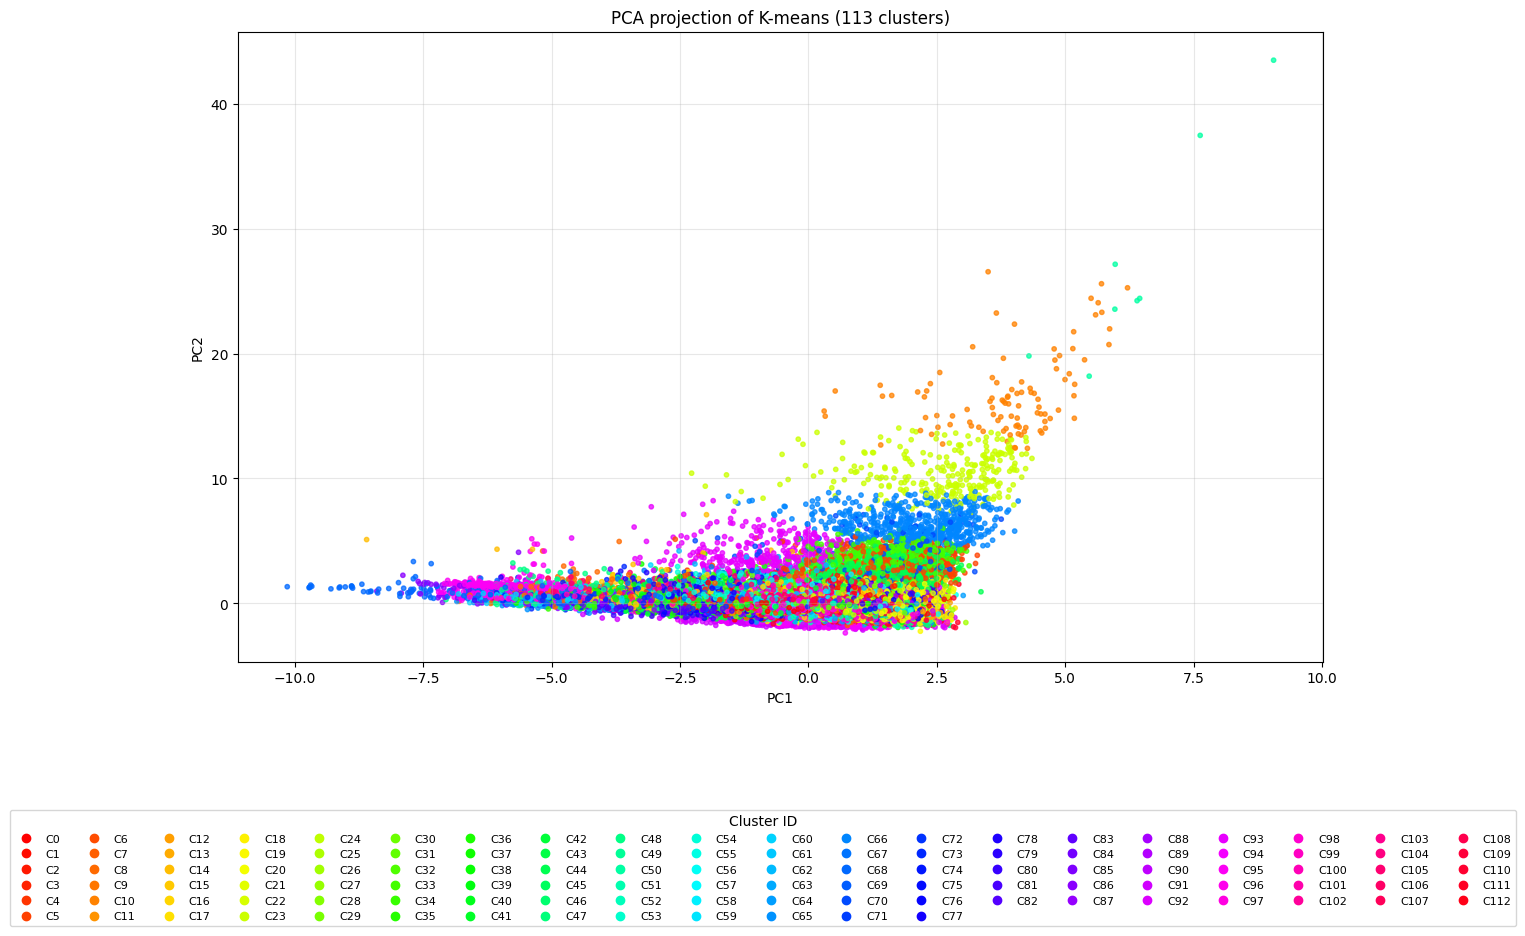

In [81]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

# -----------------------------
# PCA
# -----------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

num_clusters = k_value

# -----------------------------
# High-contrast colormap (turbo)
# -----------------------------
#colors = plt.cm.turbo(np.linspace(0, 1, num_clusters))
colors = plt.cm.hsv(np.linspace(0, 1, num_clusters))

cmap = ListedColormap(colors)

# -----------------------------
# Figure
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 10))
fig.subplots_adjust(bottom=0.25)   # Make room at bottom for wide legend

# -----------------------------
# Scatter plot
# -----------------------------
scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    cmap=cmap,
    s=10,
    alpha=0.75
)

ax.set_title("PCA projection of K-means (113 clusters)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(alpha=0.3)

# -----------------------------
# Legend (horizontal segmentation)
# -----------------------------
ncols = 20  # <--- adjust number of columns here

handles = [
    plt.Line2D([], [], marker='o', linestyle='', markersize=6, color=colors[i])
    for i in range(num_clusters)
]

fig.legend(
    handles,
    [f"C{i}" for i in range(num_clusters)],
    title="Cluster ID",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=ncols,
    fontsize=8
)

plt.show()


Note: This PCA plot looks different, from the previous one, as the data was standardized. 

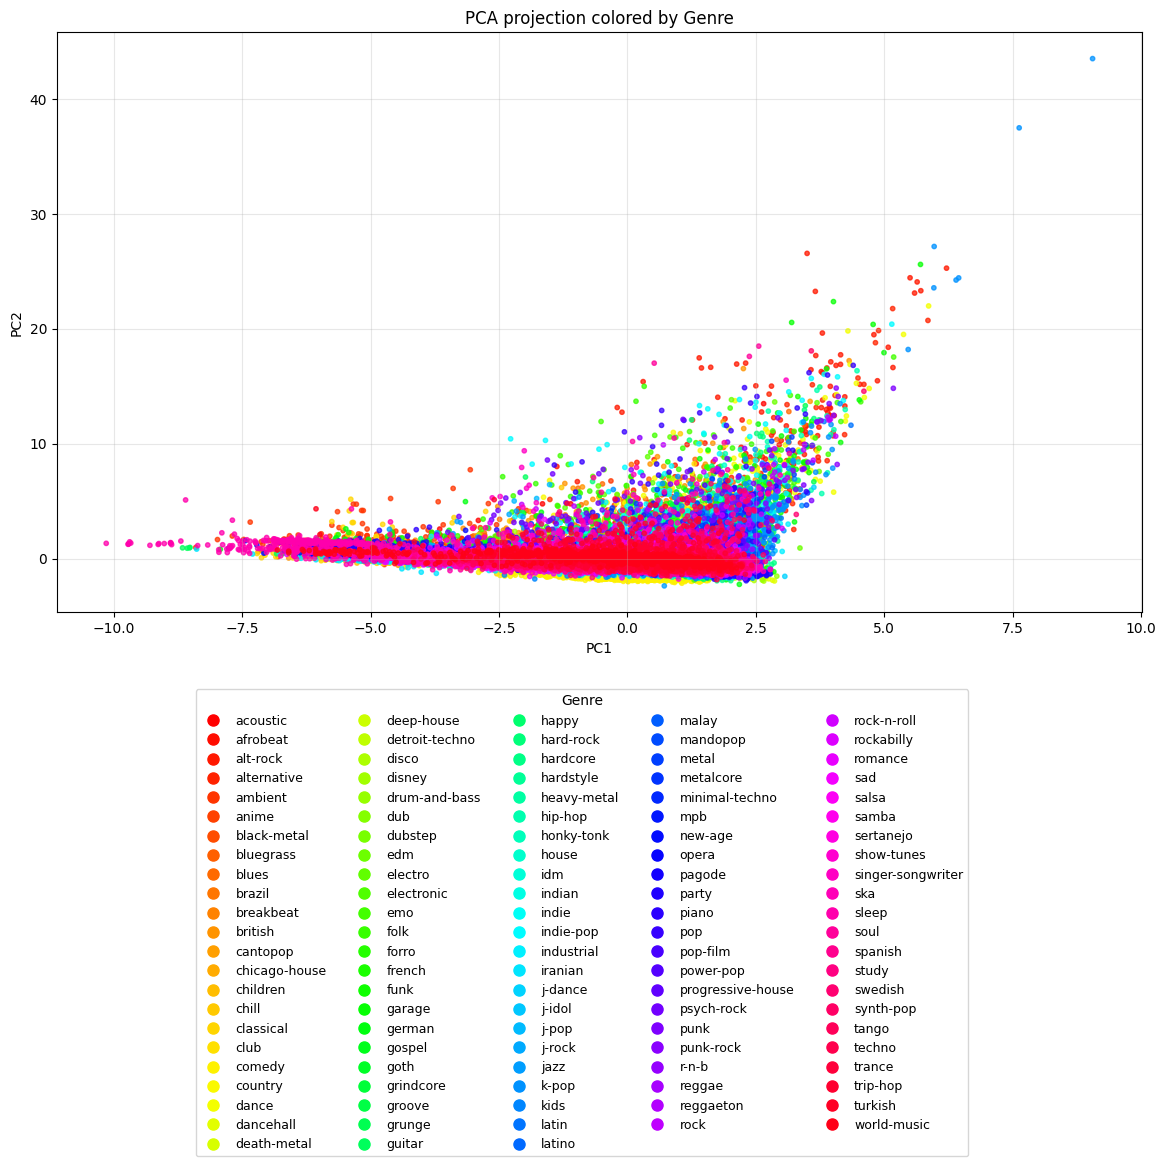

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd

# -----------------------------
# Prepare labels
# -----------------------------
genres = df_main["track_genre"].astype("category")
genre_names = genres.cat.categories
genre_codes = genres.cat.codes.values
num_genres = len(genre_names)

# -----------------------------
# PCA
# -----------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# -----------------------------
# High-contrast colormap
# -----------------------------
colors = plt.cm.hsv(np.linspace(0, 1, num_clusters))
cmap = ListedColormap(colors)

# -----------------------------
# Figure
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 10))
# Increase bottom margin to make room for horizontal legend
fig.subplots_adjust(bottom=0.3)

# -----------------------------
# Scatter plot
# -----------------------------
scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=genre_codes,
    cmap=cmap,
    s=10,
    alpha=0.75
)

ax.set_title("PCA projection colored by Genre")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(alpha=0.3)

# -----------------------------
# Legend (horizontal, 5 columns, safely below the plot)
# -----------------------------
handles = [
    plt.Line2D([], [], marker='o', linestyle='', markersize=8, color=colors[i])
    for i in range(num_genres)
]


fig.legend(
    handles,
    genre_names,
    title="Genre",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.25),  # move the legend further down
    ncol=5,                        # horizontal 5-column layout
    fontsize=9
)

plt.show()


Note, only plotting the **loadings** could also help further our understand of the different. <br>
Maybe we could test whether genres like "kids" and "children" might potentially be highly similar. 

### **Making CD-SCAN clustering of the data:**

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import pandas as pd
import numpy as np

# Assume X is your numeric feature matrix
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# DBSCAN clustering
# -----------------------------
dbscan = DBSCAN(
    eps=1.5,        # example value; tune for your data
    min_samples=5,  # example value
    metric='euclidean',
    n_jobs=-1       # parallelize
)

labels = dbscan.fit_predict(X_scaled)

# -----------------------------
# Add cluster labels back to df
# -----------------------------
df_main['dbscan_cluster'] = labels

# Summary
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)

print(f"Number of clusters found: {n_clusters}")
print(f"Number of noise points: {n_noise}")

# Optional cross-tab with genre
display(pd.crosstab(df_main['track_genre'], df_main['dbscan_cluster']))


Number of clusters found: 101
Number of noise points: 18174
dbscan_cluster  -1     0     1     2     3     4     5     6     7     8    \
track_genre                                                                  
acoustic         124   620   110    48     7     0     0     0     0     0   
afrobeat         226   364   345     6     3     0     0     0     0     0   
alt-rock         278   313   176     6     1     1     0     0     0     0   
alternative      106    66    48     4     0     0     0     0     0     0   
ambient          376   270   105    73     2     0     9    37     3     2   
...              ...   ...   ...   ...   ...   ...   ...   ...   ...   ...   
techno            40   160   117     0     0     0     0     0     0     0   
trance           118   230   225     0     0     0     0     0     0     0   
trip-hop         325   210   191     4     3     0     0     0     0     0   
turkish          101   226   446     8    12     0     0     1     0     0   
worl

In [105]:
# #Visualizing the CD-SCAN clusters in PCA: 

# from sklearn.decomposition import PCA
# import matplotlib.pyplot as plt
# from matplotlib.colors import ListedColormap

# # -----------------------------
# # PCA
# # -----------------------------
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_scaled)

# # -----------------------------
# # Discrete colormap (DBSCAN clusters)
# # -----------------------------
# unique_labels = np.unique(labels)
# num_clusters = len(unique_labels)
# colors = plt.cm.hsv(np.linspace(0,1,num_clusters))
# cmap = ListedColormap(colors)

# # -----------------------------
# # Scatter plot
# # -----------------------------
# plt.figure(figsize=(14,10))

# for i, label in enumerate(unique_labels):
#     idx = labels == label
#     lbl = "Noise" if label == -1 else f"Cluster {label}"
#     plt.scatter(
#         X_pca[idx,0],
#         X_pca[idx,1],
#         s=10,
#         alpha=0.7,
#         color=colors[i],
#         label=lbl
#     )


# plt.title("PCA projection of DBSCAN clusters")
# plt.xlabel("PC1")
# plt.ylabel("PC2")
# plt.grid(alpha=0.3)
# plt.legend(loc="best", markerscale=2, fontsize=8)
# plt.show()


In [107]:
# from sklearn.decomposition import PCA
# import matplotlib.pyplot as plt
# from matplotlib.colors import ListedColormap
# import numpy as np

# # -----------------------------
# # PCA
# # -----------------------------
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_scaled)

# # -----------------------------
# # DBSCAN clusters
# # -----------------------------
# unique_labels = np.unique(labels)
# num_clusters = len(unique_labels)

# # High-contrast colors (turbo / hsv)
# colors = plt.cm.hsv(np.linspace(0, 1, num_clusters))
# cmap = ListedColormap(colors)

# # -----------------------------
# # Figure
# # -----------------------------
# fig, ax = plt.subplots(figsize=(14, 10))
# fig.subplots_adjust(bottom=0.3)  # leave space for horizontal legend

# # -----------------------------
# # Scatter plot
# # -----------------------------
# handles = []
# for i, label in enumerate(unique_labels):
#     idx = labels == label
#     lbl = "Noise" if label == -1 else f"Cluster {label}"
#     sc = ax.scatter(
#         X_pca[idx, 0],
#         X_pca[idx, 1],
#         s=10,
#         alpha=0.7,
#         color=colors[i],
#         label=lbl
#     )
#     handles.append(sc)

# ax.set_title("PCA projection of DBSCAN clusters")
# ax.set_xlabel("PC1")
# ax.set_ylabel("PC2")
# ax.grid(alpha=0.3)

# # -----------------------------
# # Legend (horizontal, 5 columns, below plot)
# # -----------------------------
# fig.legend(
#     handles,
#     [ "Noise" if lbl=="Noise" else lbl.get_label() for lbl in handles ],
#     title="DBSCAN Cluster ID",
#     loc="lower center",
#     bbox_to_anchor=(0.5, -0.25),
#     ncol=5,
#     fontsize=9
# )

# plt.show()


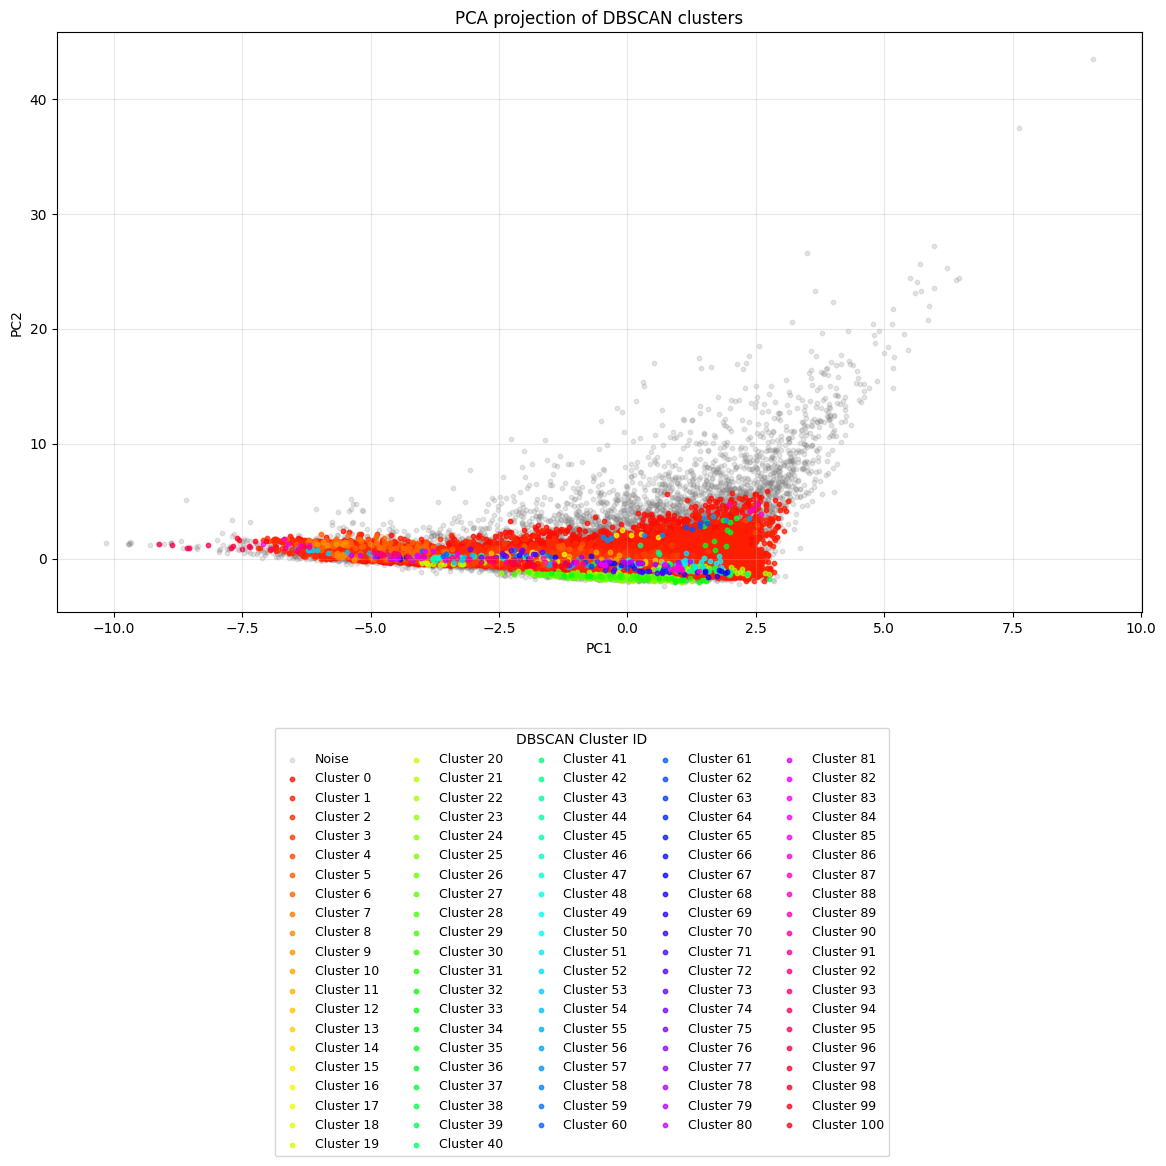

In [110]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

# -----------------------------
# PCA
# -----------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# -----------------------------
# DBSCAN clusters
# -----------------------------
unique_labels = np.unique(labels)
num_clusters = len(unique_labels)

# High-contrast colors for clusters (ignore Noise)
cluster_labels = [l for l in unique_labels if l != -1]
colors = plt.cm.hsv(np.linspace(0, 1, len(cluster_labels)))
cmap = ListedColormap(colors)

# -----------------------------
# Figure
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 10))
fig.subplots_adjust(bottom=0.3)  # leave space for horizontal legend

# -----------------------------
# Scatter plot
# -----------------------------
handles = []
for i, label in enumerate(unique_labels):
    idx = labels == label
    if label == -1:
        # Noise points: gray & transparent
        sc = ax.scatter(
            X_pca[idx, 0],
            X_pca[idx, 1],
            s=10,
            alpha=0.2,
            color='gray',
            label='Noise'
        )
    else:
        sc = ax.scatter(
            X_pca[idx, 0],
            X_pca[idx, 1],
            s=10,
            alpha=0.75,
            color=colors[i if i < len(colors) else -1],  # safe indexing
            label=f'Cluster {label}'
        )
    handles.append(sc)

ax.set_title("PCA projection of DBSCAN clusters")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(alpha=0.3)

# -----------------------------
# Legend (horizontal, 5 columns)
# -----------------------------
fig.legend(
    handles,
    [h.get_label() for h in handles],
    title="DBSCAN Cluster ID",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=5,
    fontsize=9
)

plt.show()


##### **Outdated stuff:**

**Run LSH-accelerated K-means:**

Run time: 14.8 seconds. 

**Global K-means but accelerated with LSH:**

In [43]:
# 1. Initialize K global centroids (K-means++)
# 2. For each iteration:
#       a. For each point: 
#              Use LSH to find candidate centroids
#              Assign point to the nearest among those candidates
#       b. Update all centroids globally
# 3. Repeat until convergence



Update: Not desired! This k-means clustering makes 5 clusters within each hash bucket. 

In [44]:
# #Performing K-means clustering, using LSH signatures: 

# from sklearn.cluster import KMeans

# n_items = lsh_bits.shape[0] #Should not be 'len(unique_groups)', 
#                             #Since, even tho we removed some hash buckets,
#                             #We still need to assign cluster labels back 
#                             #to the original indices (before we started removing). 

# labels_global = -1 * np.ones(n_items, dtype=int)
# cluster_base = 0

# K = 5  # number of clusters per group

# for cand_set, members in unique_groups.items():
#     indices = list(cand_set)

#     if len(indices) < 40:   # threshold; tune
#         continue

#     X_sub = X[indices]

#     kmeans = KMeans(n_clusters=K, n_init="auto", random_state=42)
#     sub_labels = kmeans.fit_predict(X_sub)

#     # assign cluster labels back to the original indices
#     for idx, label in zip(indices, sub_labels):
#         labels_global[idx] = cluster_base + label

#     cluster_base += K


Run time: 21 minutes and 13 seconds. <br>
Note: Depends on computer stats.

**Saving and loading the clustering data:**

In [45]:
# #Save the clustering results:

# ###

# if labels_global: #If you ran the k-means. 

#     # Save the cluster labels
#     np.save('cluster_labels.npy', labels_global)

#     # Or save as CSV for easy viewing
#     import pandas as pd
#     pd.DataFrame({
#         'item_index': np.arange(len(labels_global)),
#         'cluster_label': labels_global
#     }).to_csv('clustering_results.csv', index=False)

#     print(f"Clustered: {np.sum(labels_global >= 0)}/{len(labels_global)} items")
#     print(f"Number of clusters: {len(np.unique(labels_global[labels_global >= 0]))}")


In [46]:
# #Load clustering results:

# import numpy as np
# import pandas as pd

# # Load from .npy file
# labels_global = np.load('cluster_labels.npy')

# # OR load from CSV
# df_load = pd.read_csv('clustering_results.csv')
# labels_global = df_load['cluster_label'].values

# # Print summary
# print(f"Loaded: {len(labels_global)} items")
# print(f"Clustered: {np.sum(labels_global >= 0)}/{len(labels_global)} items")
# print(f"Number of clusters: {len(np.unique(labels_global[labels_global >= 0]))}")



**Inspecting the clustering results:**

In [47]:
# #Inspecting some of the clustering results: 
# print(labels_global.shape)
# print(labels_global[:50])


In [48]:
# X.shape

In [49]:
# labels_global.shape 
# #Note: LSH candidate clustering only assigned labels to a subset of rows (55,129 items), 
# #while X contains all features including some rows that were never clustered.

# #We also need to keep this in mind, when we map the original data to the clustered data.

**Visualizing clustering results using PCA and T-SNE:**

In [50]:
# # Identify clustered rows robustly (use labeled indices, handle length mismatches)
# import warnings
# labeled_indices = np.where(labels_global >= 0)[0]  # indices that received cluster labels
# # Guard: some labeled indices may be outside the current X array (shape mismatch)
# valid_mask = labeled_indices < X.shape[0]
# if not np.all(valid_mask):
#     warnings.warn(f"{np.sum(~valid_mask)} labeled indices are >= X.shape[0]={X.shape[0]} and will be ignored.")
#     labeled_indices = labeled_indices[valid_mask]
# X_clustered = X[labeled_indices]
# labels = labels_global[labeled_indices].astype(int)

# # PCA
# from sklearn.decomposition import PCA
# import matplotlib.pyplot as plt
# import numpy as np

# pca = PCA(n_components=2, random_state=42)
# X_pca = pca.fit_transform(X_clustered)

# # Map cluster IDs to sequential integers for coloring
# unique_labels = np.unique(labels)
# label_map = {old: new for new, old in enumerate(unique_labels)}
# labels_mapped = np.array([label_map[l] for l in labels])

# plt.figure(figsize=(10,6))
# plt.scatter(
#     X_pca[:,0], X_pca[:,1],
#     c=labels_mapped,
#     s=10,
#     cmap='viridis',
#     alpha=0.6
# )
# plt.xlabel("PCA 1")
# plt.ylabel("PCA 2")
# plt.title("LSH-Accelerated KMeans Clusters (PCA 2D, clustered subset)")
# plt.colorbar(label="Cluster ID")
# plt.show()

Run time: 11 seconds. 

In [51]:
# df_main.head(2)

In [52]:
# df_main.shape

In [53]:
# X_clustered

In [54]:
# X_clustered.shape

t-SNE:

In [55]:
# #t-SNE plot: 

# from sklearn.manifold import TSNE

# tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, verbose=1)
# X_tsne = tsne.fit_transform(X_clustered)

# plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_mapped, s=10, cmap='viridis', alpha=0.6)
# plt.xlabel("t-SNE 1")
# plt.ylabel("t-SNE 2")
# plt.title("LSH-Accelerated KMeans Clusters (t-SNE 2D)")
# plt.colorbar(label="Cluster ID")
# plt.show()

Run time: More than 11 minutes. 

# Outdated - Prototyping:

### **Loading subset data and generating placeholder LSH data:**

In [56]:
# root_path = "../" #All the data is outside this folder. 

Note: If we just read the e.g. first 200 lines, we will only get the track_genre = acoustic entries.
Therefore, when making the subset, we need to mix the entries that we read. 

In [57]:
# import pandas as pd
# import numpy as np

# # -----------------------------
# # 1. Load subset of CSV
# # -----------------------------
# # Load only first 200 rows (change nrows as needed)
# #df = pd.read_csv(root_path+"dataset_with_lastfm_all.csv", nrows=200)

# # Read whole CSV: 
# df = pd.read_csv(root_path+"dataset_with_lastfm_all.csv")

# # Drop 'Unnamed: 0' if present
# if "Unnamed: 0" in df.columns:
#     df = df.drop(columns=["Unnamed: 0"])

# # Take a random sample of 200 rows - overwrite the df, which covers the entire dataset. 
# df = df.sample(n=200, random_state=42)

# print("Checking how many different track genres are in the subset:")
# display( pd.DataFrame(df['track_genre'].value_counts()) )


# # Drop 'Unnamed: 0' if it exists
# if "Unnamed: 0" in df.columns:
#     df = df.drop(columns=["Unnamed: 0"])

# print("Data loaded:", df.shape)
# display(df.head())

# # Drop non-numeric columns if any (e.g., 'track_id','artists', etc.)
# numeric_df = df.select_dtypes(include=[np.number])
# print("Numeric columns used:", numeric_df.columns.tolist())


In [58]:
# #Different type of track genres in the list: 
# print(df["track_genre"].unique()) 

In [59]:
# # -----------------------------
# # 2. Generate approximate LSH-like vectors
# # -----------------------------
# # Simulate LSH signatures by random projection
# # (this approximates hashing similar vectors together)
# def generate_lsh_vectors(data, n_bits=32, seed=42):
#     rng = np.random.RandomState(seed)
#     random_planes = rng.randn(data.shape[1], n_bits)
#     projections = np.dot(data, random_planes)
#     lsh_vectors = (projections > 0).astype(int)
#     return lsh_vectors


# #generate_lsh_vectors() uses random hyperplane projection (a standard way to approximate LSH).
# #You can control the number of bits (hash length) with n_bits.

# lsh_vectors = generate_lsh_vectors(numeric_df, n_bits=64)

# lsh_vectors = lsh_vectors + np.random.normal(0, 0.01, lsh_vectors.shape) #Important: Adding noise. 
# #Without this, the place-holder clusters will be too similar, and we will only get 1 cluster.

# print("LSH-like vectors shape:", lsh_vectors.shape)

### **K-means:**

Centroid, Partition-based. <br>
Requires a user-defined K-value. <br>
Might be hard to scale up. 

In [60]:
#pip install scikit-learn

In [61]:
# from sklearn.cluster import KMeans
# from sklearn.preprocessing import StandardScaler
# import matplotlib.pyplot as plt


# n_clusters = 5 #For now we put the k-value as 5. 
# #But we can later e.g. try to put it near the amount of different genres, or something corresponding.


# # -----------------------------
# # Run K-Means clustering
# # -----------------------------
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(lsh_vectors)

# kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
# df['cluster'] = kmeans.fit_predict(X_scaled)

# print("\nCluster assignments:")
# display( pd.DataFrame(df['cluster'].value_counts()) )

# # -----------------------------
# # Visualize
# # -----------------------------
# plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df['cluster'], cmap='tab10')
# plt.title("K-Means clusters (approx LSH space)")
# plt.xlabel("Feature 1")
# plt.ylabel("Feature 2")
# plt.show()


In [62]:
# #We can compare how well clusters align with the track genre:
# pd.crosstab(df['track_genre'], df['cluster']) 

### **CURE (Clustering Using REpresentatives) algorithm:**

Hierarchical clustering. Uses representative points instead of centroids. <br>
Might be more suitable for large datasets. 

In [63]:
# #Pseudo CURE algorithm: 

# import numpy as np
# from sklearn.cluster import AgglomerativeClustering

# def simple_cure(X, n_clusters=5, shrink_factor=0.5, rep_points=10):
#     # Step 1: Hierarchical clustering
#     agg = AgglomerativeClustering(n_clusters=n_clusters)
#     labels = agg.fit_predict(X)
    
#     # Step 2: Compute representative points per cluster
#     reps = []
#     for k in range(n_clusters):
#         points = X[labels == k]
#         centroid = points.mean(axis=0)
#         dists = np.linalg.norm(points - centroid, axis=1)
#         farthest_idx = np.argsort(dists)[-rep_points:]
#         selected = points[farthest_idx]
#         reps.append(centroid + shrink_factor * (selected - centroid))
#     return labels, reps


In [64]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA
# from sklearn.cluster import AgglomerativeClustering
# from sklearn.impute import SimpleImputer

# # -----------------------------
# # 1. Prepare data
# # -----------------------------

# #numeric_df = numeric_df.dropna() #Drop the NA values. We can also use imputer transformer, to approximate some value to fill in, as covered in the course. 

# numeric_df = df.select_dtypes(include=[np.number])

# # Impute missing values (NaN) with column mean
# imputer = SimpleImputer(strategy="mean")
# X_imputed = imputer.fit_transform(numeric_df)

# # Scale
# X = StandardScaler().fit_transform(X_imputed)


# # -----------------------------
# # 2. Simplified CURE algorithm
# # -----------------------------
# def simple_cure(X, n_clusters=5, shrink_factor=0.5, rep_points=10):
#     # Step 1: Agglomerative clustering (approximation of CURE’s merging)
#     agg = AgglomerativeClustering(n_clusters=n_clusters)
#     labels = agg.fit_predict(X)
    
#     # Step 2: Compute representative points for each cluster
#     reps = []
#     for k in range(n_clusters):
#         points = X[labels == k]
#         if len(points) == 0:
#             continue
#         centroid = points.mean(axis=0)
#         dists = np.linalg.norm(points - centroid, axis=1)
#         farthest_idx = np.argsort(dists)[-rep_points:]
#         selected = points[farthest_idx]
#         # shrink points toward the centroid
#         rep_points_k = centroid + shrink_factor * (selected - centroid)
#         reps.append(rep_points_k)
#     return labels, reps

# labels, reps = simple_cure(X, n_clusters=5, shrink_factor=0.5, rep_points=10)
# df["cluster"] = labels

# # -----------------------------
# # 3. Visualize in 2D (via PCA)
# # -----------------------------
# pca = PCA(n_components=2)
# X_2d = pca.fit_transform(X)

# plt.figure(figsize=(8,6))
# plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap="tab10", alpha=0.6)
# plt.title("Simplified CURE Clustering (PCA projection)")
# plt.xlabel("PCA 1")
# plt.ylabel("PCA 2")

# # Plot representative points (also projected to 2D)
# for rep_set in reps:
#     rep_2d = pca.transform(rep_set)
#     plt.scatter(rep_2d[:, 0], rep_2d[:, 1], c="black", marker="x", s=60)

# plt.show()

# print(df["cluster"].value_counts())


In [65]:
#pip install pyclustering

In [66]:
# import pandas as pd
# import numpy as np
# from sklearn.preprocessing import StandardScaler
# from pyclustering.cluster.cure import cure
# from pyclustering.utils import timedcall
# import matplotlib.pyplot as plt

# # -----------------------------
# # 1. Load and prepare data
# # -----------------------------
# df = pd.read_csv("genre_avg_signatures.csv")
# df = df.drop(columns=["Unnamed: 0"], errors="ignore")
# df = df.sample(n=200, random_state=42)

# numeric_df = df.select_dtypes(include=[np.number])
# X = StandardScaler().fit_transform(numeric_df)

# # -----------------------------
# # 2. Run CURE clustering
# # -----------------------------
# # n_clusters: desired number of clusters
# # number_rep_points: number of representative points per cluster
# # compression: shrink factor (0–1)
# n_clusters = 5
# number_rep_points = 10
# compression = 0.5

# cure_instance = cure(data=X.tolist(),
#                      number_cluster=n_clusters,
#                      number_represent_points=number_rep_points,
#                      compression=compression)

# (ticks, _) = timedcall(cure_instance.process)
# clusters = cure_instance.get_clusters()

# # -----------------------------
# # 3. Assign cluster labels
# # -----------------------------
# labels = np.empty(X.shape[0])
# for cluster_id, indices in enumerate(clusters):
#     labels[indices] = cluster_id

# df['cluster'] = labels.astype(int)

# print("Cluster counts:\n", df['cluster'].value_counts())

# # -----------------------------
# # 4. Visualize 2D projection
# # -----------------------------
# plt.scatter(X[:, 0], X[:, 1], c=df['cluster'], cmap='tab10')
# plt.title("CURE clustering (approx view)")
# plt.xlabel("Feature 1")
# plt.ylabel("Feature 2")
# plt.show()

### **DBSCAN (Density-Based Spatial Clustering of Applications with Noise):**

Density-based. Densly packed. <br>
Note: Usually works well on PCA or UMAP dimensionality-reduced data, but can struggle with high dimensionality. 

### **Graph-Based Clustering:**

- Nodes = songs
- Edges = similarity between songs (weighted)

Community detection to identify “music communities”

**Louvain algorithm**

Two-phase. Each note starts as a community. No user-defined K-value. Works decent on large data/ is scalable. 

**Spectral clustering**

Uses eigenvectors and K-means. Can be used on k-nearest neighbors graph (k-NN graph) from LSH. 

**Girvan-Newman Algorithm**

Can find communities. Might be tricky on large graphs, although limiting edges based on the LSH buckets, might help. 